# Phase 4 — Transfer Learning with Pretrained CNNs

This notebook trains and compares pretrained image-classification backbones for the aerial object classification task. The phase starts with frozen-backbone training, then optionally fine-tunes the upper layers with a lower learning rate, and finally saves curves, metrics, checkpoints, and a transfer-learning comparison report.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports and environment setup

This cell imports the reusable project utilities, adds the project root to the Python path, and prepares the core objects needed for the transfer-learning workflow.

In [ ]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path("/content/drive/MyDrive/Aerial_Object_Classification_Detection")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import load_yaml
from src.utils.logger import get_logger
from src.utils.seed import set_seed
from src.utils.paths import load_paths_config
from src.data.classification_loader import scan_classification_dataset
from src.modeling.transfer_learning import train_transfer_learning_suite

## 2. Load configuration files

This cell loads the central path configuration, the base classification configuration, and the dedicated transfer-learning configuration. It also resolves the processed classification dataset path that was created in the earlier preprocessing phase.

In [ ]:
logger = get_logger(name="phase4_transfer_learning")

paths_config = load_paths_config(PROJECT_ROOT / "configs" / "paths.yaml")
classification_config = load_yaml(PROJECT_ROOT / "configs" / "classification_config.yaml")
transfer_learning_config = load_yaml(PROJECT_ROOT / "configs" / "transfer_learning_config.yaml")

processed_classification_root = paths_config.get(
    "processed_classification_root",
    paths_config["processed_root"] / "classification",
)

set_seed(transfer_learning_config["training"]["seed"])

print("Processed classification root:", processed_classification_root)
print("Transfer learning report path:", PROJECT_ROOT / transfer_learning_config["reporting"]["report_path"])
print("Comparison table path:", PROJECT_ROOT / transfer_learning_config["reporting"]["comparison_table_path"])
print("Configured models:", list(transfer_learning_config["models"].keys()))

Processed classification root: /content/drive/MyDrive/Aerial_Object_Classification_Detection/data/processed/classification
Transfer learning report path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/reports/transfer_learning_report.md
Comparison table path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/reports/transfer_learning_summary.csv
Configured models: ['mobilenet', 'resnet50', 'efficientnetb0']


## 3. Validate the processed classification dataset

This cell checks that the processed dataset still has the expected train, validation, and test splits, along with both expected classes. It also prints the split-wise image counts before transfer-learning training begins.

In [ ]:
scan_df = scan_classification_dataset(
    dataset_root=processed_classification_root,
    expected_splits=classification_config["dataset"]["expected_splits"],
    expected_classes=classification_config["dataset"]["expected_classes"],
    allowed_extensions=classification_config["dataset"]["allowed_extensions"],
)

display(scan_df)

pivot_counts = scan_df.pivot(index="split", columns="class_name", values="image_count")
display(pivot_counts)

,split,class_name,image_count,class_dir_exists
0,train,bird,1414,True
1,train,drone,1248,True
2,valid,bird,217,True
3,valid,drone,225,True
4,test,bird,121,True
5,test,drone,94,True


class_name,bird,drone
split,,
test,121,94
train,1414,1248
valid,217,225


## 4. Review the transfer-learning experiment setup

This cell displays the high-level experiment configuration so that the selected backbones, frozen-stage epochs, fine-tuning epochs, and learning rates are visible before training starts.

In [ ]:
display(pd.DataFrame([
    {
        "model_name": model_name,
        "enabled": model_cfg["enabled"],
        "backbone": model_cfg["backbone"],
        "dense_units": model_cfg["dense_units"],
        "dropout_rate": model_cfg["dropout_rate"],
        "fine_tune_enabled": model_cfg["fine_tune"]["enabled"],
        "unfreeze_top_layers": model_cfg["fine_tune"]["unfreeze_top_layers"],
    }
    for model_name, model_cfg in transfer_learning_config["models"].items()
]))
print("Frozen epochs:", transfer_learning_config["training"]["epochs_frozen"])
print("Fine-tune epochs:", transfer_learning_config["training"]["epochs_finetune"])
print("Frozen LR:", transfer_learning_config["training"]["frozen_learning_rate"])
print("Fine-tune LR:", transfer_learning_config["training"]["finetune_learning_rate"])

,model_name,enabled,backbone,dense_units,dropout_rate,fine_tune_enabled,unfreeze_top_layers
0,mobilenet,True,mobilenetv2,128,0.3,True,20
1,resnet50,True,resnet50,256,0.4,True,30
2,efficientnetb0,True,efficientnetb0,160,0.3,True,20


Frozen epochs: 8
Fine-tune epochs: 8
Frozen LR: 0.001
Fine-tune LR: 0.0001


## 5. Train the transfer-learning model suite

This cell runs the full transfer-learning pipeline for all enabled models in the configuration. For each selected backbone, it performs frozen-head training first, optionally fine-tunes the upper layers with a lower learning rate, evaluates validation and test performance, saves checkpoints and JSON artifacts, exports accuracy/loss curves, and writes a comparison report.

In [7]:
artifacts = train_transfer_learning_suite(
    dataset_root=processed_classification_root,
    project_root=PROJECT_ROOT,
    transfer_learning_config=transfer_learning_config,
    logger=logger,
)

artifacts.keys()

2026-03-30 19:03:26 | INFO | phase4_transfer_learning | Training transfer-learning model: mobilenet


Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.


2026-03-30 19:03:28 | INFO | phase4_transfer_learning | Starting frozen-head training for mobilenet...


Epoch 1/8
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9115 - loss: 0.2149 - precision: 0.8992 - recall: 0.9214
Epoch 1: val_loss improved from None to 0.15341, saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/best_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.9530 - loss: 0.1344 - precision: 0.9488 - recall: 0.9511 - val_accuracy: 0.9548 - val_loss: 0.1534 - val_precision: 0.9289 - val_recall: 0.9867 - learning_rate: 0.0010
Epoch 2/8
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9917 - loss: 0.0527 - precision: 0.9862 - recall: 0.9963
Epoch 2: val_loss improved from 0.15341 to 0.10193, saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/best_model.keras

Epoch 2: finished saving model to /con

2026-03-30 19:19:34 | INFO | phase4_transfer_learning | Starting fine-tuning for mobilenet...


...

Epoch 1/8
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9270 - loss: 0.2004 - precision: 0.9193 - recall: 0.9284
Epoch 1: val_loss improved from None to 0.10534, saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/efficientnetb0/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/efficientnetb0/best_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.9628 - loss: 0.1182 - precision: 0.9614 - recall: 0.9591 - val_accuracy: 0.9774 - val_loss: 0.1053 - val_precision: 0.9694 - val_recall: 0.9867 - learning_rate: 0.0010
Epoch 2/8
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9904 - loss: 0.0525 - precision: 0.9894 - recall: 0.9902
Epoch 2: val_loss improved from 0.10534 to 0.07931, saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/efficientnetb0/best_model.keras

Epoch 2: finished savin

2026-03-30 22:22:49 | INFO | phase4_transfer_learning | Starting fine-tuning for efficientnetb0...


Epoch 8/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9966 - loss: 0.0366 - precision: 0.9964 - recall: 0.9965
Epoch 8: val_loss improved from 0.07688 to 0.07356, saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/efficientnetb0/best_model.keras

Epoch 8: finished saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/efficientnetb0/best_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.9970 - loss: 0.0357 - precision: 0.9960 - recall: 0.9976 - val_accuracy: 0.9887 - val_loss: 0.0736 - val_precision: 0.9911 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 9/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 0.0294 - precision: 1.0000 - recall: 1.0000
Epoch 9: val_loss improved from 0.07356 to 0.07254, saving model to /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/efficientnetb0/best_model.keras

Epoch 9: finis

2026-03-30 23:03:35 | INFO | phase4_transfer_learning | Saving final model for efficientnetb0...


dict_keys(['results', 'summary_df', 'comparison_table_path', 'report_path'])

## 6. Review the model comparison table

This cell displays the final comparison table containing the main validation/test metrics, training time, speed label, deployment note, and saved best-model path for each transfer-learning backbone.

In [8]:
summary_df = artifacts["summary_df"]
display(summary_df)

,model_name,backbone,val_accuracy,val_f1_score,test_accuracy,test_f1_score,training_time_seconds,speed_bucket,deployment_note,best_model_path
0,efficientnetb0,efficientnetb0,0.986425,0.986667,0.981395,0.978723,4291.913510,medium,Reasonably lightweight with a good balance of ...,/content/drive/MyDrive/Aerial_Object_Classific...
1,resnet50,resnet50,0.966063,0.967603,0.958140,0.953368,8201.833738,slower,Stronger feature extractor but heavier for edg...,/content/drive/MyDrive/Aerial_Object_Classific...
2,mobilenet,mobilenetv2,0.945701,0.948718,0.948837,0.944162,1695.236906,fast,Highly deployment-friendly and lightweight.,/content/drive/MyDrive/Aerial_Object_Classific...


## 7. Inspect saved artifact paths model by model

This cell prints the important saved artifact locations for each trained transfer-learning model, including the best checkpoint, final model, history JSON, metrics JSON, and exported curve images.

In [9]:
for result in artifacts["results"]:
    print("=" * 100)
    print("Model name:", result["model_name"])
    print("Backbone:", result["backbone"])
    print("Best model path:", result["best_model_path"])
    print("Final model path:", result["final_model_path"])
    print("History path:", result["history_path"])
    print("Metrics path:", result["metrics_path"])
    print("Accuracy curve path:", result["accuracy_curve_path"])
    print("Loss curve path:", result["loss_curve_path"])

Model name: mobilenet
Backbone: mobilenetv2
Best model path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/best_model.keras
Final model path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/final_model.keras
History path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/history.json
Metrics path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/mobilenet/metrics.json
Accuracy curve path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/training/mobilenet_accuracy.png
Loss curve path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/figures/training/mobilenet_loss.png
Model name: resnet50
Backbone: resnet50
Best model path: /content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/resnet50/best_model.keras
Final model path: /content/drive/MyDrive/Aerial_Obj

## 8. Display saved accuracy and loss curves

This cell loads and displays the saved learning curves for each trained backbone so the training stability and validation behaviour can be visually compared.


Displaying curves for: mobilenet


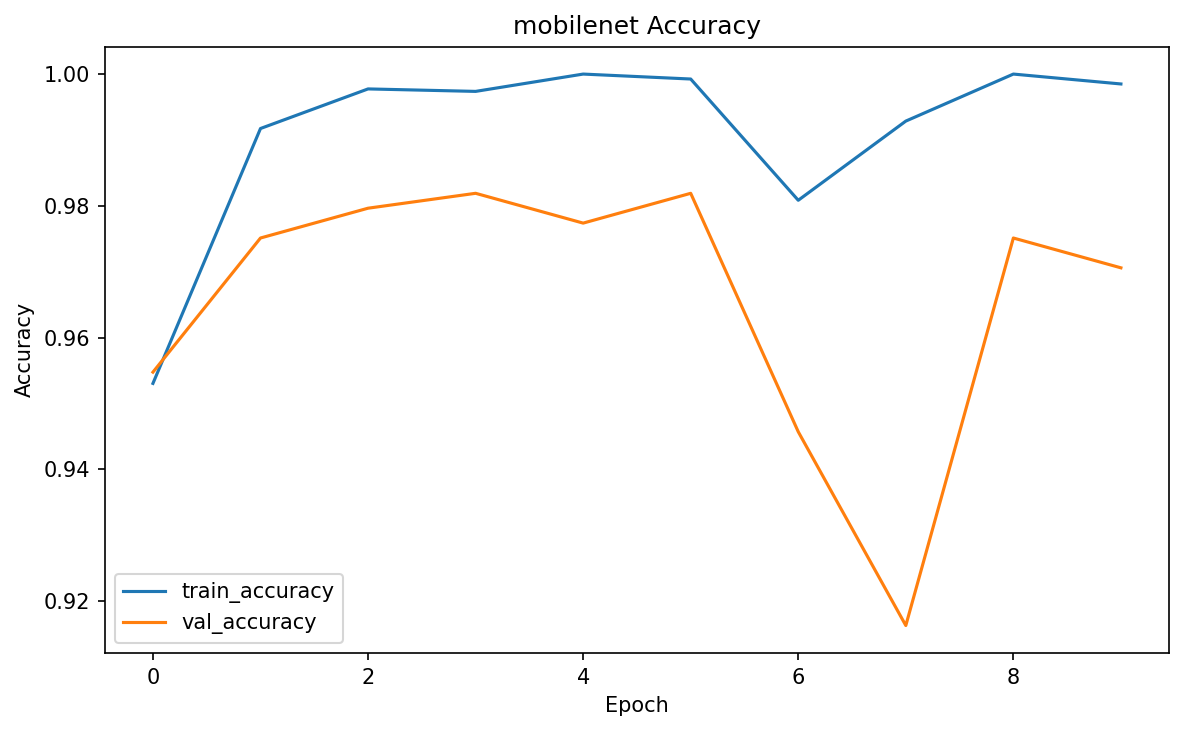

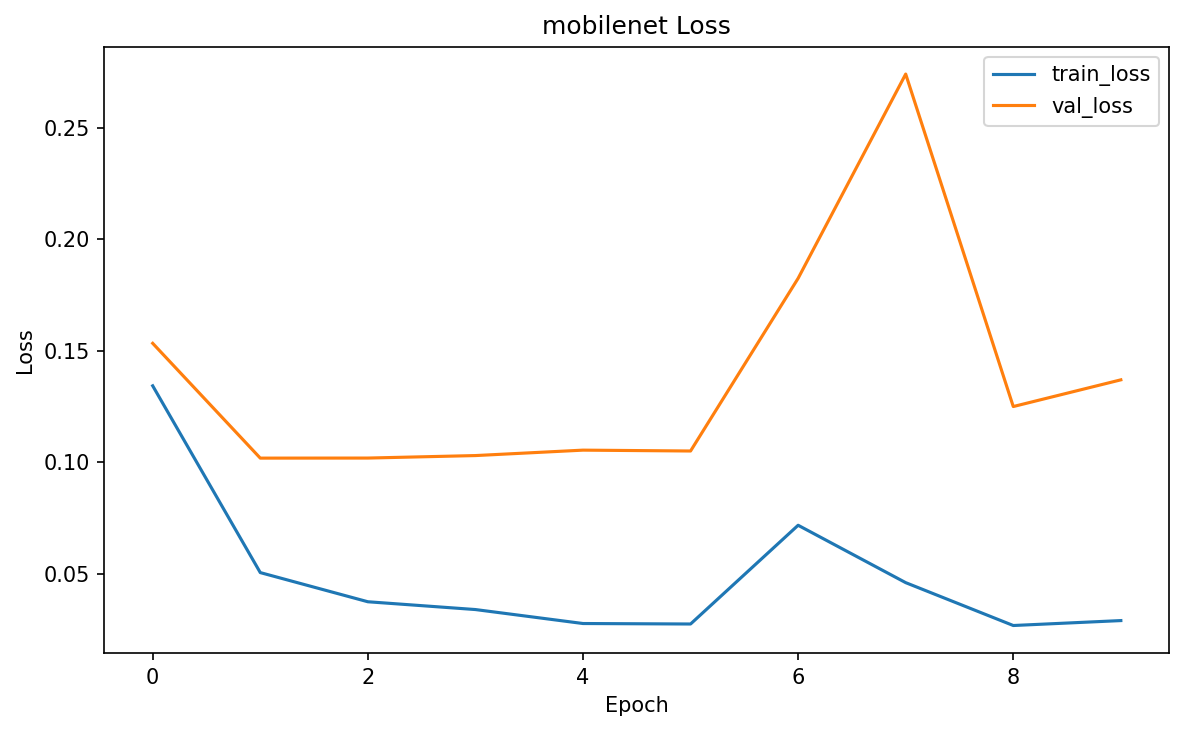


Displaying curves for: resnet50


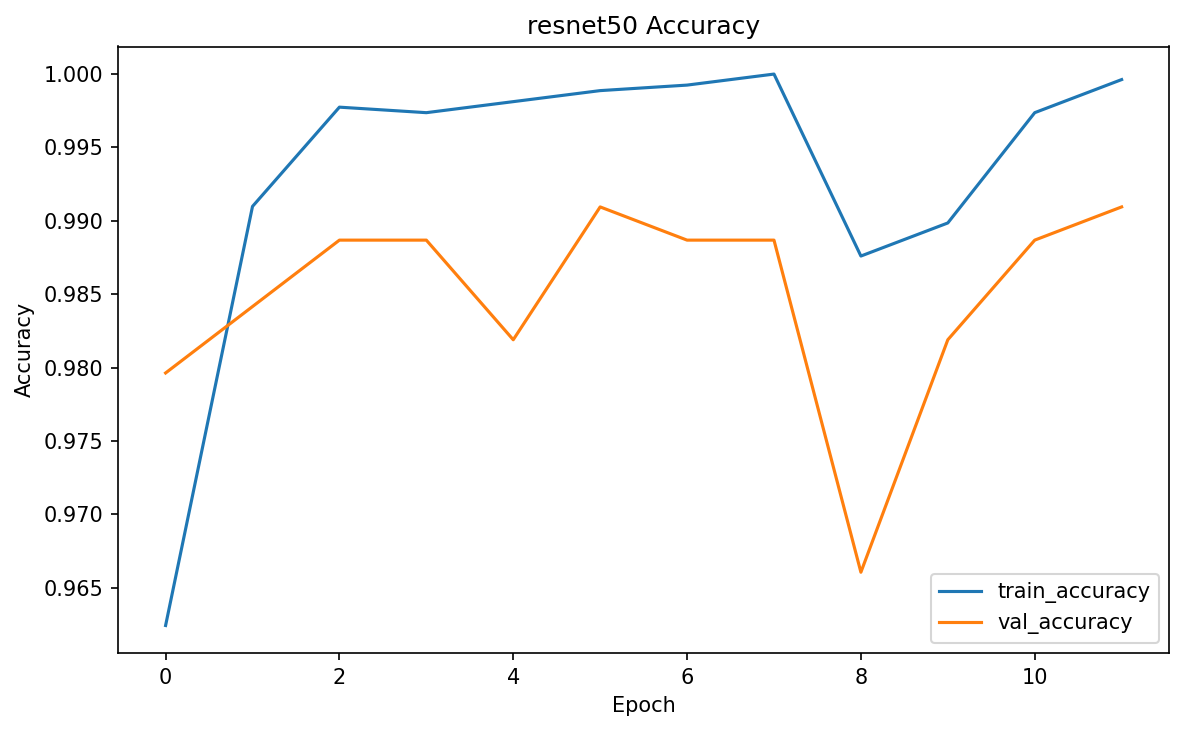

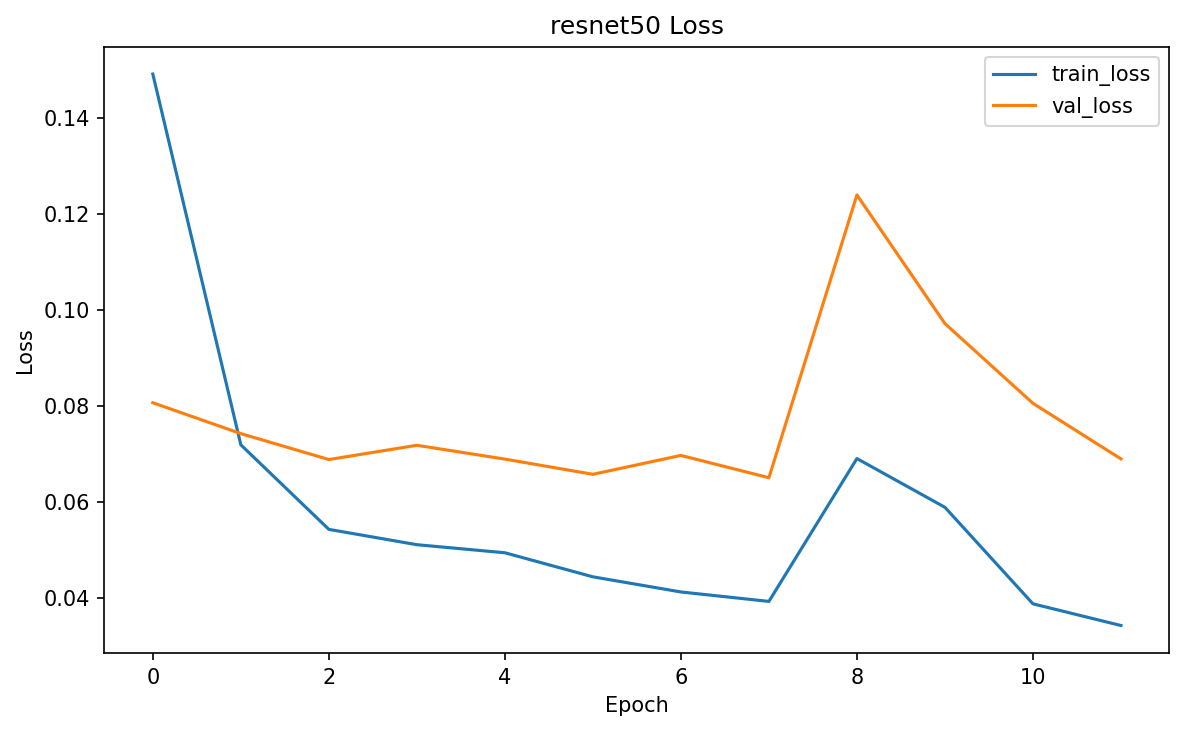


Displaying curves for: efficientnetb0


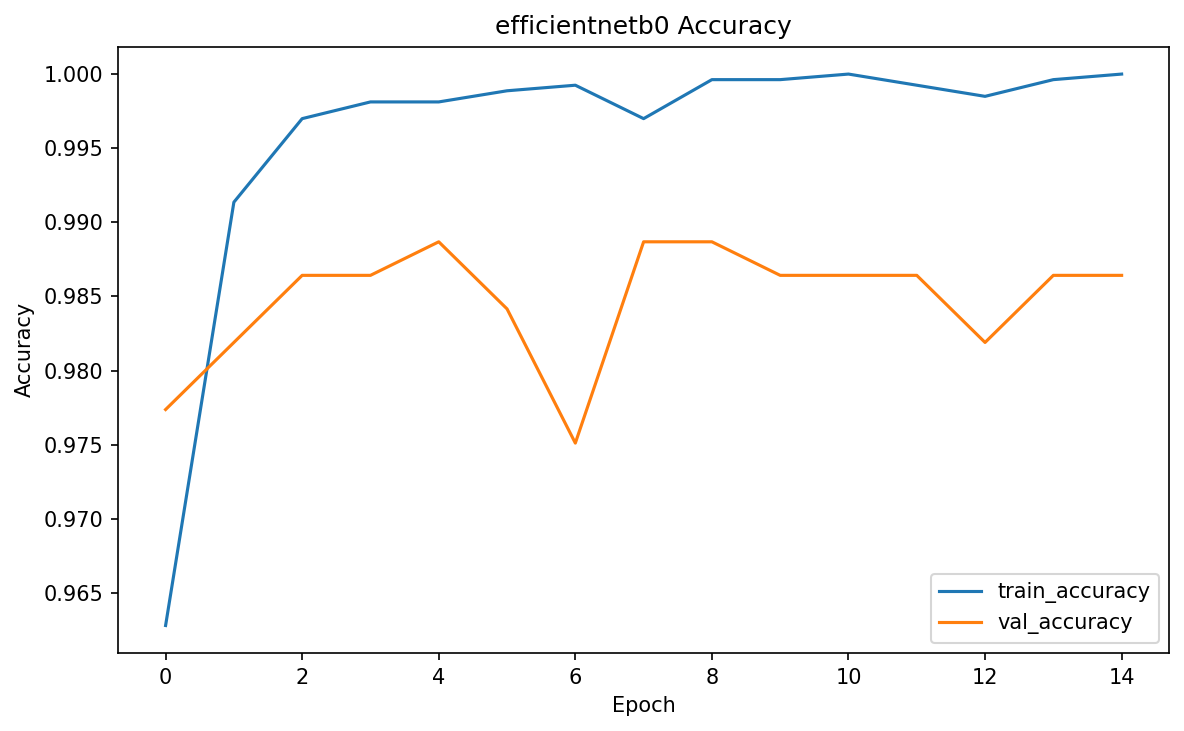

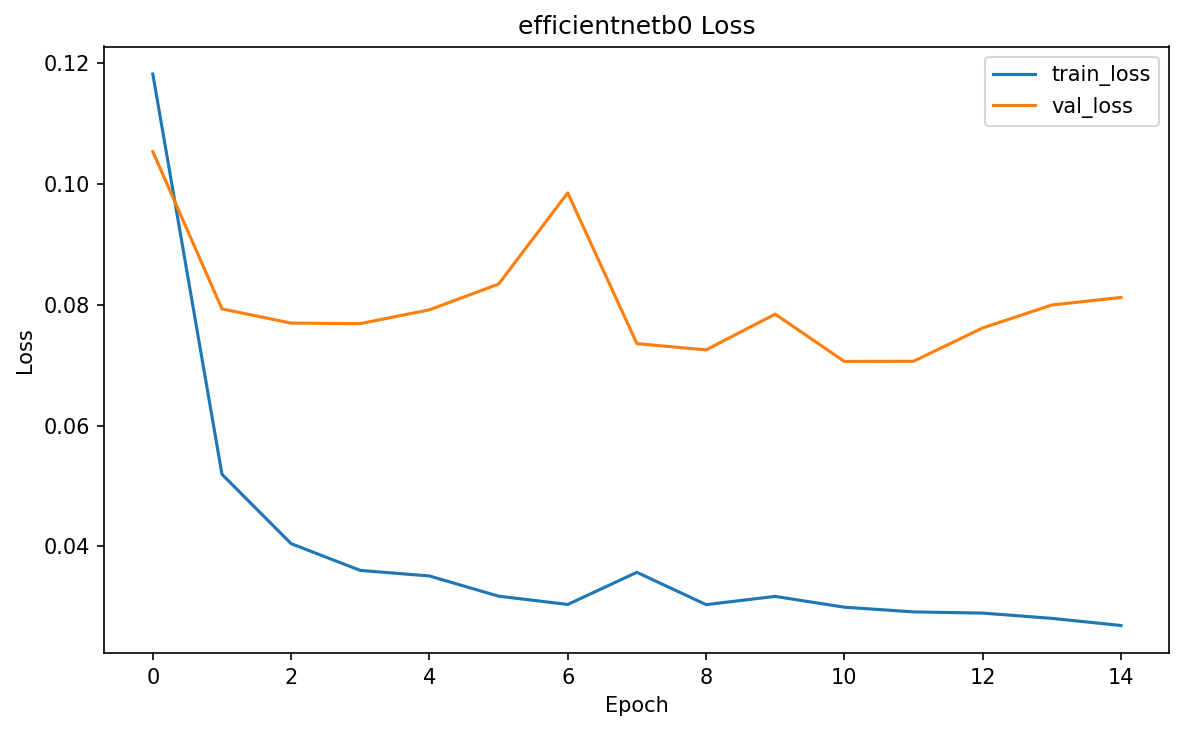

In [10]:
for result in artifacts["results"]:
    print(f"\nDisplaying curves for: {result['model_name']}")
    display(Image(filename=str(result["accuracy_curve_path"])))
    display(Image(filename=str(result["loss_curve_path"])))

## 9. Inspect saved metrics JSON files

This cell reads the saved metrics JSON for each model so that validation accuracy, test accuracy, F1-score, training time, and deployment note can be reviewed directly in the notebook.

In [11]:
for result in artifacts["results"]:
    print("=" * 100)
    print("Metrics for:", result["model_name"])
    metrics_payload = json.loads(Path(result["metrics_path"]).read_text(encoding="utf-8"))
    print(json.dumps(metrics_payload, indent=2)[:2500], "...")

Metrics for: mobilenet
{
  "model_name": "mobilenet",
  "backbone": "mobilenetv2",
  "class_names": [
    "bird",
    "drone"
  ],
  "frozen_epochs_completed": 6,
  "finetune_epochs_completed": 4,
  "best_epoch": 2,
  "training_time_seconds": 1695.236906206,
  "validation": {
    "accuracy": 0.9457013574660633,
    "precision": 0.9135802469135802,
    "recall": 0.9866666666666667,
    "f1_score": 0.9487179487179487,
    "confusion_matrix": [
      [
        196,
        21
      ],
      [
        3,
        222
      ]
    ],
    "classification_report": {
      "bird": {
        "precision": 0.9849246231155779,
        "recall": 0.9032258064516129,
        "f1-score": 0.9423076923076923,
        "support": 217.0
      },
      "drone": {
        "precision": 0.9135802469135802,
        "recall": 0.9866666666666667,
        "f1-score": 0.9487179487179487,
        "support": 225.0
      },
      "accuracy": 0.9457013574660633,
      "macro avg": {
        "precision": 0.949252435014579

## 10. Review the transfer-learning report

This cell opens the generated markdown report that summarizes the best model so far, the speed-versus-performance trade-offs, and the deployment suitability of each backbone.

In [12]:
report_text = Path(artifacts["report_path"]).read_text(encoding="utf-8")
print(report_text)

# Transfer Learning Report

## Overview

This phase compares multiple pretrained backbones for aerial object classification using a two-stage strategy: frozen-head training followed by optional fine-tuning of the upper backbone layers.

## Best Model So Far

- Best model: **efficientnetb0**
- Validation accuracy: **0.9864**
- Test accuracy: **0.9814**
- Validation F1-score: **0.9867**
- Training time (seconds): **4291.91**

## Model Trade-Offs

### efficientnetb0
- Backbone: efficientnetb0
- Validation accuracy: 0.9864
- Test accuracy: 0.9814
- Training time (seconds): 4291.91
- Speed bucket: medium
- Deployment note: Reasonably lightweight with a good balance of efficiency and accuracy.

### resnet50
- Backbone: resnet50
- Validation accuracy: 0.9661
- Test accuracy: 0.9581
- Training time (seconds): 8201.83
- Speed bucket: slower
- Deployment note: Stronger feature extractor but heavier for edge deployment.

### mobilenet
- Backbone: mobilenetv2
- Validation accuracy: 0.9457
- Test a

## 11. Conclusion

At this stage, the transfer-learning phase is complete:
- pretrained backbones were selected and trained
- frozen-head training was performed first
- upper layers were optionally fine-tuned with a smaller learning rate
- best and final model files were saved for each backbone
- history and metrics JSON artifacts were stored
- accuracy and loss curves were exported
- model trade-offs were summarized in a markdown report and comparison table

This now gives a strong pretrained-model baseline to compare against the earlier custom CNN results.